In [10]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


['net_dpr', 'nade_ratio', 'headshotperhit', 'engagement_rate', 'survivability', 'efficiency', 'rounds_played', 'clutches', 'rounds_won', 'match_wins', 'matches_played', 'clutch_rate', 'win_rate', 'match_win_rate', 'raw_score', 'round_weight', 'score_adj', 'score_percentile', 'score_z', 'tier']
shape: (14, 14)
┌───────────┬────────────┬────────────────┬─────────────────┬───┬────────────────┬─────────────┬───────────┬────────────────┐
│ net_dpr   ┆ nade_ratio ┆ headshotperhit ┆ engagement_rate ┆ … ┆ matches_played ┆ clutch_rate ┆ win_rate  ┆ match_win_rate │
│ ---       ┆ ---        ┆ ---            ┆ ---             ┆   ┆ ---            ┆ ---         ┆ ---       ┆ ---            │
│ f64       ┆ f64        ┆ f64            ┆ f64             ┆   ┆ f64            ┆ f64         ┆ f64       ┆ f64            │
╞═══════════╪════════════╪════════════════╪═════════════════╪═══╪════════════════╪═════════════╪═══════════╪════════════════╡
│ 1.0       ┆ -0.000867  ┆ 0.247033       ┆ 0.673377       

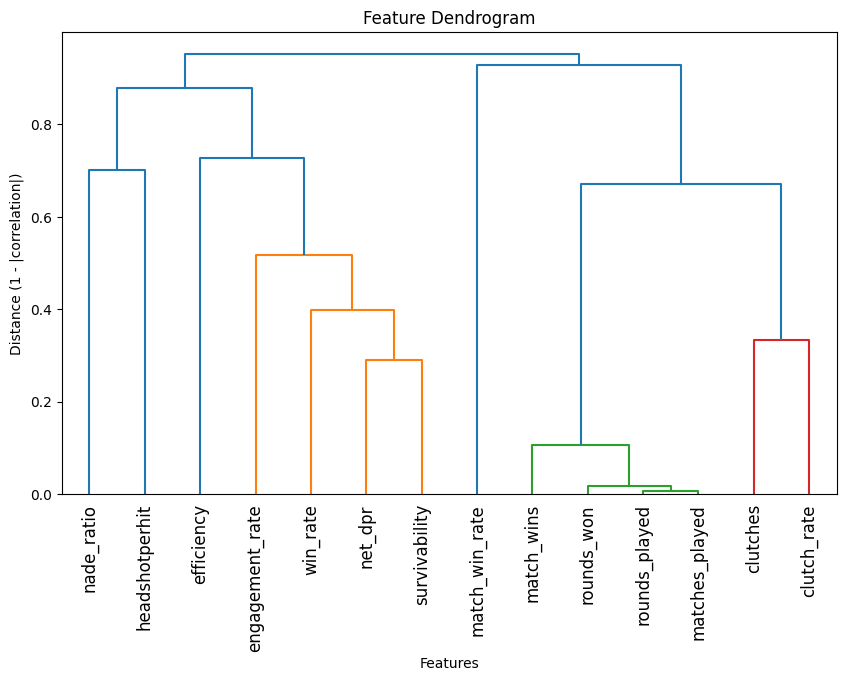

In [4]:
import polars as pl

df = pl.read_csv("player_rankings_pca.csv")

# drop player column
df = df.select(pl.all().exclude("player"))

print(df.columns)

# select specific columns (must be strings!)


# correlation matrix
corr = df.corr()

print(corr)
corr_np = corr.to_numpy()

dist = 1 - np.abs(corr_np)
dist_condensed = squareform(dist, checks=False)

Z = linkage(dist_condensed, method="average")

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df.columns)
plt.title("Feature Dendrogram")
plt.xlabel("Features")
plt.ylabel("Distance (1 - |correlation|)")
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
import polars as pl

data = pl.read_csv("complete_aggregation3.csv")
# drop player column
df = data.select(pl.all().exclude("player"))

print(df.columns)

# select specific columns (must be strings!)

corr = df.corr()
corr_np = corr.to_numpy()

dist = 1 - np.abs(corr_np)
dist_condensed = squareform(dist, checks=False)

Z = linkage(dist_condensed, method="average")

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df.columns)
plt.title("Feature Dendrogram")
plt.xlabel("Features")
plt.ylabel("Distance (1 - |correlation|)")
plt.xticks(rotation='vertical')

In [11]:
df = pl.read_csv("player_rankings_pca.csv")

# drop player column
#df = df.select(pl.all().exclude("player"))

#print(df.columns)

# select specific columns (must be strings!)
df = df.select(["net_dpr","nade_ratio","headshotperhit","engagement_rate","survivability","efficiency","rounds_played","clutches","rounds_won", "match_wins","matches_played","clutch_rate","win_rate","match_win_rate"])
# Ward linkage usually behaves much better for compact numeric clusters
linkage_data = linkage(df, method="ward")

results = []
cluster_size_data = {}

for k in range(2, 6):
    labels = fcluster(linkage_data, k, criterion="maxclust")

    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts = dict(zip(unique.tolist(), counts.tolist()))
    min_cluster_size = counts.min()
    n_singletons = np.sum(counts == 1)
    smallest_pct = min_cluster_size / len(labels)

    sil = silhouette_score(df, labels)
    ch = calinski_harabasz_score(df, labels)
    db = davies_bouldin_score(df, labels)

    print(f"\n=== k = {k} ===")
    print("Cluster sizes:", cluster_counts)
    print(f"Smallest cluster size: {min_cluster_size}")
    print(f"Singleton clusters: {n_singletons}")
    print(f"Silhouette: {sil:.4f}, CH: {ch:.2f}, DB: {db:.4f}")

    if n_singletons > 0:
        print("Warning: clustering still contains singleton outlier clusters.")
    elif smallest_pct < 0.02:
        print("Warning: clustering is very imbalanced.")

    results.append({
        "n_clusters": k,
        "silhouette_score": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster_size),
        "singleton_clusters": int(n_singletons)
    })

    cluster_size_data[k] = cluster_counts

results_df = pd.DataFrame(results)
print("\nSummary table:")
print(results_df)


=== k = 2 ===
Cluster sizes: {1: 8007, 2: 3702}
Smallest cluster size: 3702
Singleton clusters: 0
Silhouette: 0.6040, CH: 16438.40, DB: 0.6392

=== k = 3 ===
Cluster sizes: {1: 8007, 2: 2659, 3: 1043}
Smallest cluster size: 1043
Singleton clusters: 0
Silhouette: 0.5797, CH: 22729.18, DB: 0.5976

=== k = 4 ===
Cluster sizes: {1: 8007, 2: 2659, 3: 729, 4: 314}
Smallest cluster size: 314
Singleton clusters: 0
Silhouette: 0.5777, CH: 24210.61, DB: 0.5702

=== k = 5 ===
Cluster sizes: {1: 4574, 2: 3433, 3: 2659, 4: 729, 5: 314}
Smallest cluster size: 314
Singleton clusters: 0
Silhouette: 0.4772, CH: 28364.48, DB: 0.6272

Summary table:
   n_clusters  silhouette_score  calinski_harabasz  davies_bouldin  \
0           2          0.604014       16438.399174        0.639170   
1           3          0.579724       22729.175383        0.597582   
2           4          0.577687       24210.613717        0.570202   
3           5          0.477158       28364.482618        0.627181   

   min_cl

In [13]:
import polars as pl
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# show more columns/rows in Polars printouts
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(50)
pl.Config.set_fmt_str_lengths(200)

df_full = pl.read_csv("player_rankings_pca.csv")

feature_cols = [
    "net_dpr", "nade_ratio", "headshotperhit", "engagement_rate",
    "survivability", "efficiency", "rounds_played", "clutches",
    "rounds_won", "match_wins", "matches_played",
    "clutch_rate", "win_rate", "match_win_rate"
]

# keep player separately
players = df_full.get_column("player")

# features only
df = df_full.select(feature_cols)

# use numpy array for scipy/sklearn
X = df.to_numpy()

# hierarchical clustering
linkage_data = linkage(X, method="ward")

results = []
cluster_size_data = {}

for k in range(2, 6):
    labels = fcluster(linkage_data, k, criterion="maxclust")

    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts = dict(zip(unique.tolist(), counts.tolist()))
    min_cluster_size = counts.min()
    n_singletons = np.sum(counts == 1)
    smallest_pct = min_cluster_size / len(labels)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    print(f"\n=== k = {k} ===")
    print("Cluster sizes:", cluster_counts)
    print(f"Smallest cluster size: {min_cluster_size}")
    print(f"Singleton clusters: {n_singletons}")
    print(f"Silhouette: {sil:.4f}, CH: {ch:.2f}, DB: {db:.4f}")

    if n_singletons > 0:
        print("Warning: clustering still contains singleton outlier clusters.")
    elif smallest_pct < 0.02:
        print("Warning: clustering is very imbalanced.")

    results.append({
        "n_clusters": k,
        "silhouette_score": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster_size),
        "singleton_clusters": int(n_singletons)
    })

    cluster_size_data[k] = cluster_counts

results_df = pd.DataFrame(results)
print("\nSummary table:")
print(results_df)
chosen_k = 4

labels = fcluster(linkage_data, chosen_k, criterion="maxclust")

clustered_df = pl.DataFrame({
    "player": players,
    "cluster": labels,
    **{col: df.get_column(col) for col in df.columns}
})

print(clustered_df)
player_clusters = clustered_df.select(["player", "cluster"]).sort(["cluster", "player"])
print(player_clusters)
cluster_means = (
    clustered_df
    .group_by("cluster")
    .agg(
        pl.exclude(["player", "cluster"]).mean()
    )
    .sort("cluster")
)

print("\nCluster means:")
print(cluster_means)
cluster_summary = (
    clustered_df
    .group_by("cluster")
    .agg(
        [pl.len().alias("n_players")] +
        [pl.col(c).mean().alias(f"{c}_mean") for c in feature_cols] +
        [pl.col(c).std().alias(f"{c}_std") for c in feature_cols] +
        [pl.col(c).min().alias(f"{c}_min") for c in feature_cols] +
        [pl.col(c).max().alias(f"{c}_max") for c in feature_cols]
    )
    .sort("cluster")
)

print("\nCluster summary:")
print(cluster_summary)


=== k = 2 ===
Cluster sizes: {1: 8007, 2: 3702}
Smallest cluster size: 3702
Singleton clusters: 0
Silhouette: 0.6040, CH: 16438.40, DB: 0.6392

=== k = 3 ===
Cluster sizes: {1: 8007, 2: 2659, 3: 1043}
Smallest cluster size: 1043
Singleton clusters: 0
Silhouette: 0.5797, CH: 22729.18, DB: 0.5976

=== k = 4 ===
Cluster sizes: {1: 8007, 2: 2659, 3: 729, 4: 314}
Smallest cluster size: 314
Singleton clusters: 0
Silhouette: 0.5777, CH: 24210.61, DB: 0.5702

=== k = 5 ===
Cluster sizes: {1: 4574, 2: 3433, 3: 2659, 4: 729, 5: 314}
Smallest cluster size: 314
Singleton clusters: 0
Silhouette: 0.4772, CH: 28364.48, DB: 0.6272

Summary table:
   n_clusters  silhouette_score  calinski_harabasz  davies_bouldin  \
0           2          0.604014       16438.399174        0.639170   
1           3          0.579724       22729.175383        0.597582   
2           4          0.577687       24210.613717        0.570202   
3           5          0.477158       28364.482618        0.627181   

   min_cl

In [14]:
import polars as pl
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# show more columns/rows in Polars printouts
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(50)
pl.Config.set_fmt_str_lengths(200)

df_full = pl.read_csv("player_rankings_pca.csv")

feature_cols = [
    "net_dpr", "nade_ratio", "headshotperhit", "engagement_rate",
    "survivability", "efficiency",
    "clutch_rate", "win_rate", "match_win_rate"
]

# keep player separately
players = df_full.get_column("player")

# features only
df = df_full.select(feature_cols)

# use numpy array for scipy/sklearn
X = df.to_numpy()

# hierarchical clustering
linkage_data = linkage(X, method="ward")

results = []
cluster_size_data = {}

for k in range(2, 6):
    labels = fcluster(linkage_data, k, criterion="maxclust")

    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts = dict(zip(unique.tolist(), counts.tolist()))
    min_cluster_size = counts.min()
    n_singletons = np.sum(counts == 1)
    smallest_pct = min_cluster_size / len(labels)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    print(f"\n=== k = {k} ===")
    print("Cluster sizes:", cluster_counts)
    print(f"Smallest cluster size: {min_cluster_size}")
    print(f"Singleton clusters: {n_singletons}")
    print(f"Silhouette: {sil:.4f}, CH: {ch:.2f}, DB: {db:.4f}")

    if n_singletons > 0:
        print("Warning: clustering still contains singleton outlier clusters.")
    elif smallest_pct < 0.02:
        print("Warning: clustering is very imbalanced.")

    results.append({
        "n_clusters": k,
        "silhouette_score": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster_size),
        "singleton_clusters": int(n_singletons)
    })

    cluster_size_data[k] = cluster_counts

results_df = pd.DataFrame(results)
print("\nSummary table:")
print(results_df)
chosen_k = 4

labels = fcluster(linkage_data, chosen_k, criterion="maxclust")

clustered_df = pl.DataFrame({
    "player": players,
    "cluster": labels,
    **{col: df.get_column(col) for col in df.columns}
})

print(clustered_df)
player_clusters = clustered_df.select(["player", "cluster"]).sort(["cluster", "player"])
print(player_clusters)
cluster_means = (
    clustered_df
    .group_by("cluster")
    .agg(
        pl.exclude(["player", "cluster"]).mean()
    )
    .sort("cluster")
)

print("\nCluster means:")
print(cluster_means)
cluster_summary = (
    clustered_df
    .group_by("cluster")
    .agg(
        [pl.len().alias("n_players")] +
        [pl.col(c).mean().alias(f"{c}_mean") for c in feature_cols] +
        [pl.col(c).std().alias(f"{c}_std") for c in feature_cols] +
        [pl.col(c).min().alias(f"{c}_min") for c in feature_cols] +
        [pl.col(c).max().alias(f"{c}_max") for c in feature_cols]
    )
    .sort("cluster")
)

print("\nCluster summary:")
print(cluster_summary)


=== k = 2 ===
Cluster sizes: {1: 5483, 2: 6226}
Smallest cluster size: 5483
Singleton clusters: 0
Silhouette: 0.4869, CH: 16018.57, DB: 0.7031

=== k = 3 ===
Cluster sizes: {1: 5483, 2: 1365, 3: 4861}
Smallest cluster size: 1365
Singleton clusters: 0
Silhouette: 0.4298, CH: 14296.61, DB: 0.6935

=== k = 4 ===
Cluster sizes: {1: 3328, 2: 2155, 3: 1365, 4: 4861}
Smallest cluster size: 1365
Singleton clusters: 0
Silhouette: 0.3966, CH: 17657.70, DB: 0.7090

=== k = 5 ===
Cluster sizes: {1: 3328, 2: 2155, 3: 1365, 4: 3031, 5: 1830}
Smallest cluster size: 1365
Singleton clusters: 0
Silhouette: 0.3505, CH: 16711.52, DB: 0.8314

Summary table:
   n_clusters  silhouette_score  calinski_harabasz  davies_bouldin  \
0           2          0.486944       16018.568108        0.703091   
1           3          0.429767       14296.612961        0.693512   
2           4          0.396598       17657.704186        0.709020   
3           5          0.350499       16711.517930        0.831350   

   

In [15]:
import polars as pl
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# show more columns/rows in Polars printouts
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(50)
pl.Config.set_fmt_str_lengths(200)

df_full = pl.read_csv("player_rankings_pca.csv")

feature_cols = ["rounds_played", "clutches",
    "rounds_won", "match_wins", "matches_played"
]

# keep player separately
players = df_full.get_column("player")

# features only
df = df_full.select(feature_cols)

# use numpy array for scipy/sklearn
X = df.to_numpy()

# hierarchical clustering
linkage_data = linkage(X, method="ward")

results = []
cluster_size_data = {}

for k in range(2, 6):
    labels = fcluster(linkage_data, k, criterion="maxclust")

    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts = dict(zip(unique.tolist(), counts.tolist()))
    min_cluster_size = counts.min()
    n_singletons = np.sum(counts == 1)
    smallest_pct = min_cluster_size / len(labels)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    print(f"\n=== k = {k} ===")
    print("Cluster sizes:", cluster_counts)
    print(f"Smallest cluster size: {min_cluster_size}")
    print(f"Singleton clusters: {n_singletons}")
    print(f"Silhouette: {sil:.4f}, CH: {ch:.2f}, DB: {db:.4f}")

    if n_singletons > 0:
        print("Warning: clustering still contains singleton outlier clusters.")
    elif smallest_pct < 0.02:
        print("Warning: clustering is very imbalanced.")

    results.append({
        "n_clusters": k,
        "silhouette_score": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster_size),
        "singleton_clusters": int(n_singletons)
    })

    cluster_size_data[k] = cluster_counts

results_df = pd.DataFrame(results)
print("\nSummary table:")
print(results_df)
chosen_k = 4

labels = fcluster(linkage_data, chosen_k, criterion="maxclust")

clustered_df = pl.DataFrame({
    "player": players,
    "cluster": labels,
    **{col: df.get_column(col) for col in df.columns}
})

print(clustered_df)
player_clusters = clustered_df.select(["player", "cluster"]).sort(["cluster", "player"])
print(player_clusters)
cluster_means = (
    clustered_df
    .group_by("cluster")
    .agg(
        pl.exclude(["player", "cluster"]).mean()
    )
    .sort("cluster")
)

print("\nCluster means:")
print(cluster_means)
cluster_summary = (
    clustered_df
    .group_by("cluster")
    .agg(
        [pl.len().alias("n_players")] +
        [pl.col(c).mean().alias(f"{c}_mean") for c in feature_cols] +
        [pl.col(c).std().alias(f"{c}_std") for c in feature_cols] +
        [pl.col(c).min().alias(f"{c}_min") for c in feature_cols] +
        [pl.col(c).max().alias(f"{c}_max") for c in feature_cols]
    )
    .sort("cluster")
)

print("\nCluster summary:")
print(cluster_summary)


=== k = 2 ===
Cluster sizes: {1: 6923, 2: 4786}
Smallest cluster size: 4786
Singleton clusters: 0
Silhouette: 0.5518, CH: 12937.38, DB: 0.6574

=== k = 3 ===
Cluster sizes: {1: 6923, 2: 577, 3: 4209}
Smallest cluster size: 577
Singleton clusters: 0
Silhouette: 0.5919, CH: 23069.39, DB: 0.5544

=== k = 4 ===
Cluster sizes: {1: 6923, 2: 577, 3: 2619, 4: 1590}
Smallest cluster size: 577
Singleton clusters: 0
Silhouette: 0.5612, CH: 27358.61, DB: 0.5675

=== k = 5 ===
Cluster sizes: {1: 6923, 2: 448, 3: 129, 4: 2619, 5: 1590}
Smallest cluster size: 129
Singleton clusters: 0
Silhouette: 0.5629, CH: 30875.81, DB: 0.5607

Summary table:
   n_clusters  silhouette_score  calinski_harabasz  davies_bouldin  \
0           2          0.551839       12937.378408        0.657358   
1           3          0.591853       23069.391532        0.554360   
2           4          0.561173       27358.607240        0.567463   
3           5          0.562906       30875.812802        0.560683   

   min_clu